In [80]:
import scipy.stats as stats
import scipy.signal as signal
import numpy as np
import matplotlib.pyplot as plt
from datetime import timedelta
from IPython.display import Math, display

import pandas as pd

In [2]:
plt.style.use('ggplot')
plt.rcParams['legend.labelcolor'] = 'black'

# Simulation

In this section, we will explore statistical simulation techniques based on historical data. The application will be to use is to simulate wind speed data based on historical data.

## Data Visualization

The data is from the Kelmarsh wind farm in the UK. The data is from the year 2016 and is sampled at 10 minute intervals, [https://zenodo.org/records/5841834#.YgpBQ_so-V7](https://zenodo.org/records/5841834#.YgpBQ_so-V7)

In [3]:
df = pd.read_parquet("wind_speed.parquet")

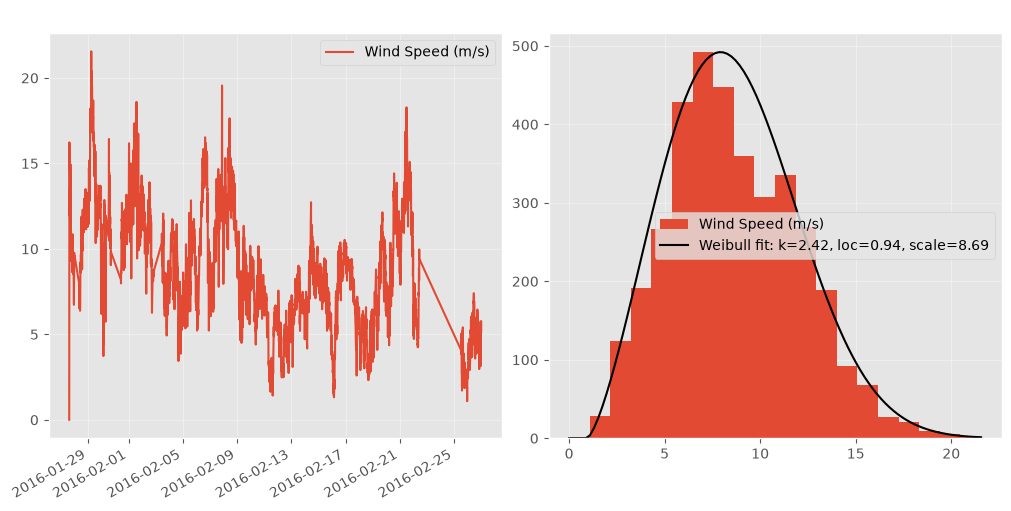

In [4]:
_, axes = plt.subplots(ncols=2, figsize=(10, 5), constrained_layout=True)
bins = 20
df.plot(ax=axes[0])
df.hist(ax=axes[1], bins=bins, legend=True)

kappa, loc, scale = stats.weibull_min.fit(df.iloc[:,0].values)
x = np.linspace(df.values.min(), df.values.max(), 100)
pdf = stats.weibull_min.pdf(x, c=kappa, loc=loc, scale=scale)

pdf *= pd.cut(df.iloc[:,0], bins=bins).value_counts().max()/np.max(pdf)
axes[1].plot(x, pdf, color='black', label=f'Weibull fit: k={kappa:.2f}, loc={loc:.2f}, scale={scale:.2f}')
axes[1].legend();

## Probability integral transform

This is an important result that is used in statistical simulation. It states that a random variable $X$ that has a continuous distribution and a cumulative distribution function (CDF) $F_X(x)$, then the random variable $Y = F_X(X)$ is uniformly distributed on the interval [0, 1].

Moreover, if $U$ is a random variable that is uniformly distributed on the interval [0, 1], then the random variable $X = F_X^{-1}(U)$ has the same distribution as $X$.

This is an useful result when we want to simulate random variables that follow a given distribution. We will do this by first sampling a normal distribution, and then transforming it to a uniform distribution using the CDF before transforming it to the Weibull distribution using the inverse CDF.

In [5]:
N = 1_000
x_normal = np.random.normal(loc=2.0, scale=3.2, size=N)
x_uniform = stats.norm.cdf(x_normal, loc=2.0, scale=3.2)
x_weibull = stats.weibull_min.ppf(x_uniform, c =kappa, loc=loc, scale=scale)

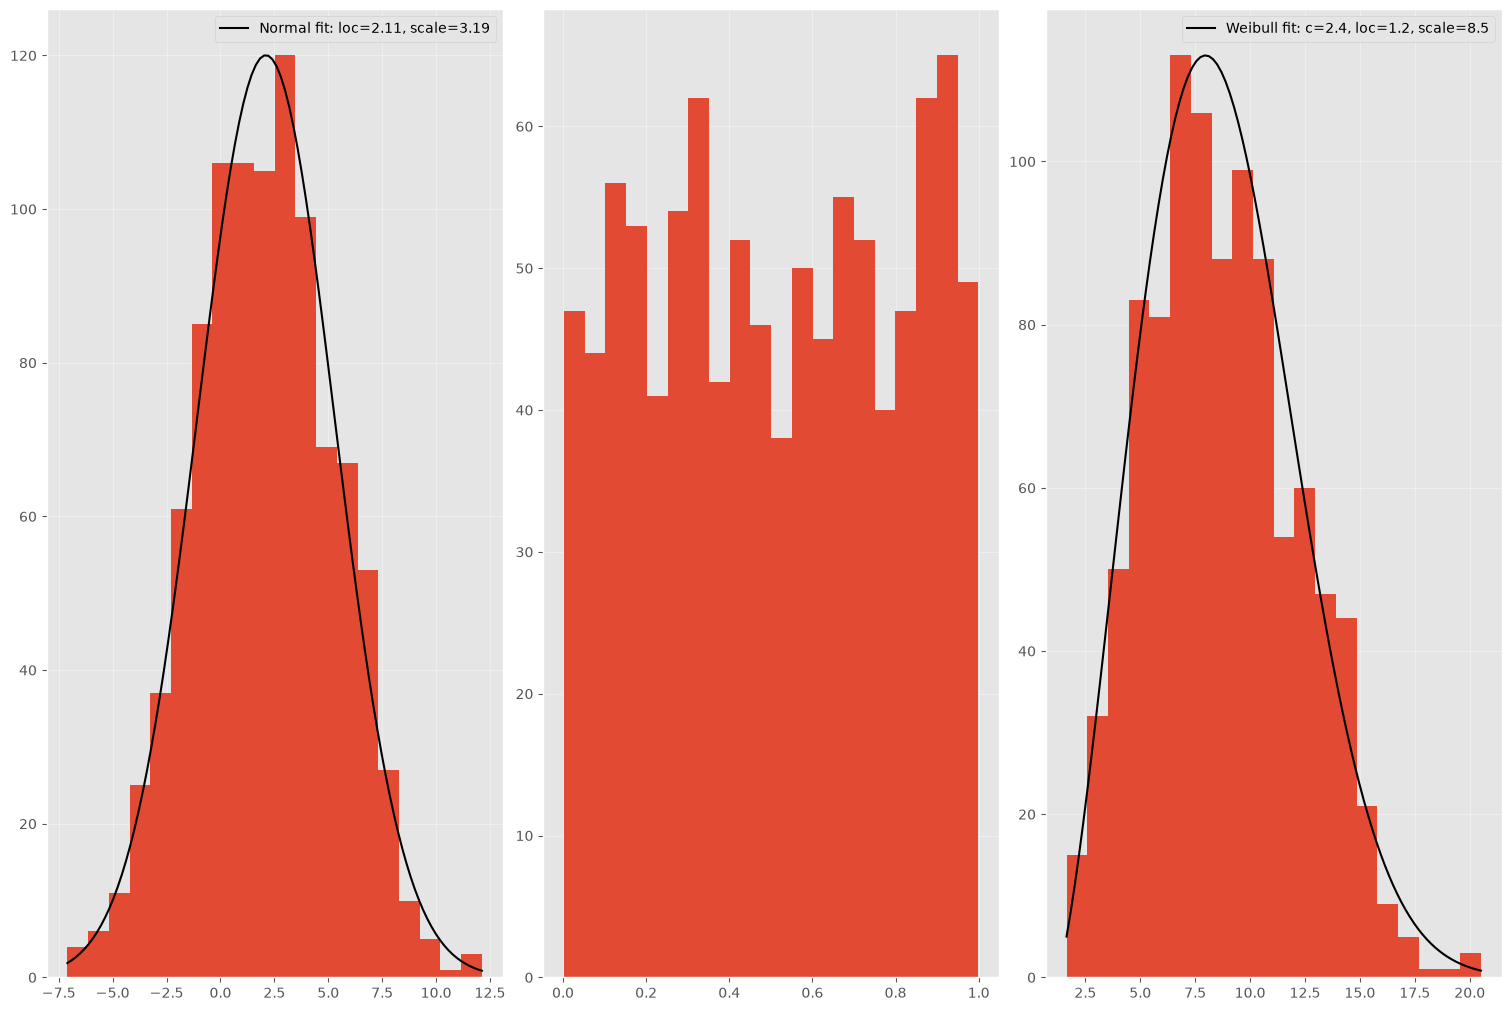

In [6]:
fix, axes = plt.subplots(ncols=3, figsize=(15, 10), constrained_layout=True)

bins = 20

axes[0].hist(x_normal, bins=bins)
normal_loc, normal_scale = stats.norm.fit(x_normal)
x = np.linspace(x_normal.min(), x_normal.max(), 100)
pdf = stats.norm.pdf(x, loc=normal_loc, scale=normal_scale)
pdf *= pd.cut(x_normal, bins=bins).value_counts().max()/np.max(pdf)
axes[0].plot(x, pdf, color='black', label=f'Normal fit: loc={normal_loc:.2f}, scale={normal_scale:.2f}')
axes[0].legend()
axes[1].hist(x_uniform, bins=bins)

axes[2].hist(x_weibull, bins=bins)
weibull_c, x_weibull_loc, weibull_scale = stats.weibull_min.fit(x_weibull)
x = np.linspace(x_weibull.min(), x_weibull.max(), 100)
pdf = stats.weibull_min.pdf(x, c=weibull_c, loc=x_weibull_loc, scale=weibull_scale)
pdf *= pd.cut(x_weibull, bins=bins).value_counts().max()/np.max(pdf)
axes[2].plot(x, pdf, color='black', label=f'Weibull fit: c={weibull_c:.1f}, loc={x_weibull_loc:.1f}, scale={weibull_scale:.1f}')
axes[2].legend();

## Simulating Wind Speed Data

The goal is to simulate wind speed data that has the same distribution and correlation structure as the historical data. We want this to hold both for the wind speed distribution and the change in wind speed distribution.

We will start by fitting a distribution to the change in wind speed data as well as repeating the Weibull fit to the wind speed data as done in the previous section.

In [14]:
# To get the change in wind speed distribution, we will need to account for the gaps in the data.
sampling_period = timedelta(seconds=10*60)
sampling_rate = 1 / sampling_period.total_seconds()
gaps = df.index.to_series().diff() > sampling_period
chunk_id = gaps.cumsum()

chunks = [chunk for _, chunk in df.groupby(chunk_id)]

In [15]:
df_diff = pd.concat([(pd.concat([chunk, -1*chunk.diff(periods=-1)], axis=1).dropna()) for chunk in chunks], axis=0)
df_diff.columns = ['wind_speed', 'wind_speed_diff']
wind_speed, wind_speed_diff = df_diff['wind_speed'], df_diff['wind_speed_diff']

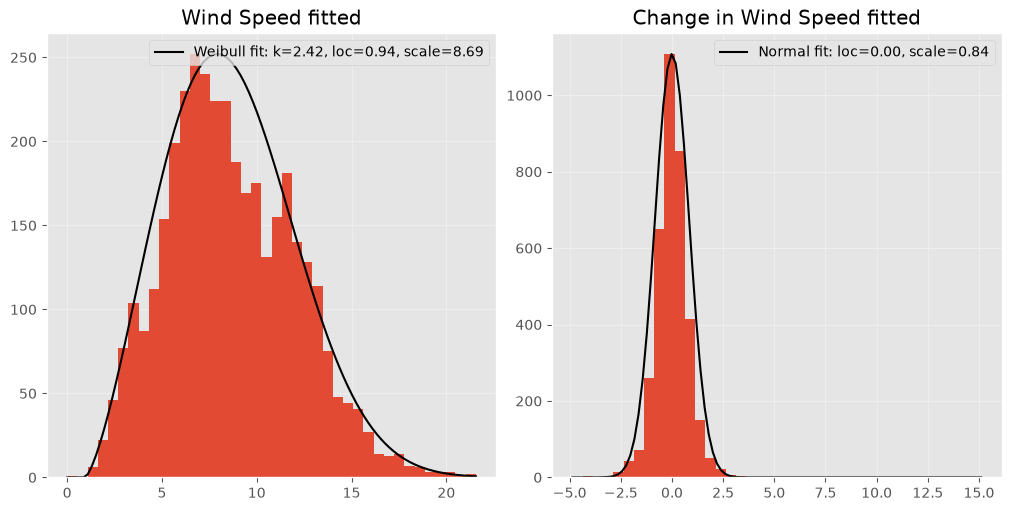

In [35]:
kappa, loc, scale = stats.weibull_min.fit(wind_speed.values)
x_weibull = np.linspace(wind_speed.values.min(), wind_speed.values.max(), 100)
pdf = stats.weibull_min.pdf(x_weibull, c=kappa, loc=loc, scale=scale)

loc_diff, scale_diff = stats.norm.fit(wind_speed_diff.values)
x_normal = np.linspace(wind_speed_diff.values.min(),wind_speed_diff.values.max(), 100)
pdf_diff = stats.norm.pdf(x_normal, loc=loc_diff, scale=scale_diff)

fig, axes = plt.subplots(ncols=2, figsize=(10, 5), constrained_layout=True)
bins = 40
pdf *= pd.cut(wind_speed, bins=bins).value_counts().max()/np.max(pdf)

axes[0].hist(wind_speed, bins=bins)
axes[0].plot(x_weibull, pdf, color='black', label=f'Weibull fit: k={kappa:.2f}, loc={loc:.2f}, scale={scale:.2f}')
axes[0].set_title("Wind Speed fitted", color='black')
axes[0].legend()

axes[1].hist(wind_speed_diff, bins=bins)
pdf_diff *= pd.cut(wind_speed_diff, bins=bins).value_counts().max()/np.max(pdf_diff)
axes[1].plot(x_normal, pdf_diff, color='black', label=f'Normal fit: loc={loc_diff:.2f}, scale={scale_diff:.2f}');
axes[1].set_title("Change in Wind Speed fitted", color='black')
axes[1].legend();

# NORmal to anything (NORTA)

This is a technique from the [paper](https://www.ressources-actuarielles.net/EXT/ISFA/1226.nsf/0/5d499a3efc8ae4dfc125756c00391ca6/$FILE/NORTA.pdf)

Say we want to generate multiple random variables that have a given correlation structure and distributions. If the distributions we wand are **closed under convolution** then we could create new random variables by adding these together. However, this only holds through for a few continuous distributions (Normal, Poisson, Chi-Square, Gamma, Binomial). If we instead take advantage of the probability integral transform, we can generate random variables with any distribution and correlation structure. The steps are as follows:

1. Generate a multivariate normal random variable with the desired correlation structure.
2. Transform the multivariate normal random variable to a uniform random variable using the CDF.
3. Transform the uniform random variable to the desired distribution using the inverse CDF.


**Important**: Note that this also appies to correlation with itself. Meaning that we can have a single random variable, but which is a sequence (time series) in which each step is highly correlated with the previous step. This is important for simulating wind speed data, as wind speed is highly correlated with itself over time.


We will use an autoregressive model to generate the wind speed data such that it is correlated with itself over time. An autoregressive model of order 1 (AR(1)) is defined as:

$$X_t = \phi X_{t-1} + \epsilon_t$$

where $\phi$ is the autoregressive parameter and $\epsilon_t$ is a white noise process.

We will assume white Gaussian noise for the $\epsilon_t$ process. Note that we do not know which variance to use for the white noise process, only that after doing the probability integral transform, we want the resulting change in wind speed distribution to have the same variance as the historical data. We will use a simple search to find the variance of the white noise process that results in approximately the same variance as the historical data after the probability integral transform.

### Side quest - Computation speed

We want to generate AR(1) data with a given correlation structure. We can do this with a simple for loop, but this is slow in Python. We can speed this up by using the `scipy.signal.lfilter` function, which is implemented in C and is much faster than a for loop in Python.

In [48]:
N = 100_000 # Datapoints to simulate
phi = 0.9 # Initial guess for the autoregressive parameter

In [49]:
%%timeit
_ = signal.lfilter([1], [1, -phi], np.random.normal(size=N))

1.87 ms ± 134 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [50]:
%%timeit
x = np.zeros(N)
for t in range(1, N):
    x[t] = phi * x[t-1] + np.random.normal(0)


88.8 ms ± 10.5 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


### Simulation

Note that to create the correlated normal distribution, we set the white noise process to have a standard deviation of $\sigma_\epsilon = \sqrt{(1-\phi^2)}$. This is necessary to ensure that the resulting AR(1) process has a variance of 1, which is required by the NORTA method. If not, the stats.norm.cdf(x) will not be uniformly distributed on the interval [0, 1] and the resulting Weibull distribution will not get the correct parameters.

In [95]:
N = 100_000 # Datapoints to simulate
phi = 0.95 # Initial guess for the autoregressive parameter
search_count = 100
for iteration in range(search_count):
    eps_std = np.sqrt(1 - phi**2)
    x = signal.lfilter([1], [1, -phi], np.random.normal(scale=eps_std, size=N))

    uniform = stats.norm.cdf(x)
    simulated_wind_speed = stats.weibull_min.ppf(uniform, c=kappa, loc=loc, scale=scale)
    simulated_wind_speed_diff = np.diff(simulated_wind_speed)
    current_var = np.var(simulated_wind_speed_diff)

    phi = phi  + (1 - phi) * (1 - np.sqrt(scale_diff**2/current_var))

    display(Math(fr'$\phi$ = {phi:.4f}, $\sigma_\epsilon$ = {eps_std:.4f}, var(diff(simulated_wind_speed)) = {current_var:.4f} Iteration {iteration+1}'), clear=True)

<IPython.core.display.Math object>

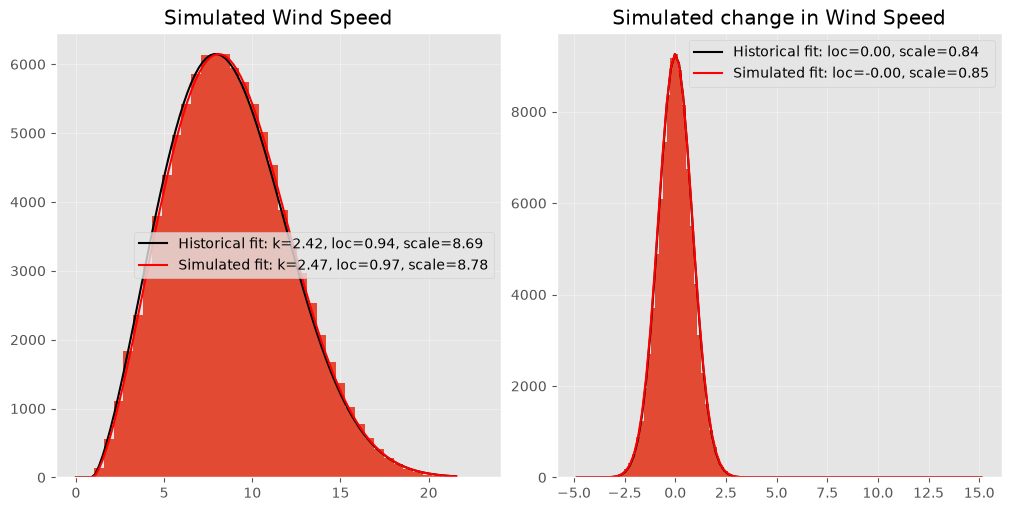

In [99]:
fig, axes = plt.subplots(ncols=2, figsize=(10, 5), constrained_layout=True)
bins = 40
x_weibull = np.linspace(wind_speed.values.min(), wind_speed.values.max(), 100)
pdf = stats.weibull_min.pdf(x_weibull, c=kappa, loc=loc, scale=scale)
kappa_sim, loc_sim, scale_sim = stats.weibull_min.fit(simulated_wind_speed)
pdf_sim = stats.weibull_min.pdf(x_weibull, c=kappa_sim, loc=loc_sim, scale=scale_sim)

pdf *= pd.cut(simulated_wind_speed, bins=bins).value_counts().max()/np.max(pdf)
pdf_sim *= pd.cut(simulated_wind_speed, bins=bins).value_counts().max()/np.max(pdf_sim)

axes[0].hist(simulated_wind_speed, bins=bins)
axes[0].plot(x_weibull, pdf, color='black', label=f'Historical fit: k={kappa:.2f}, loc={loc:.2f}, scale={scale:.2f}')
axes[0].plot(x_weibull, pdf_sim, color='red', label=f'Simulated fit: k={kappa_sim:.2f}, loc={loc_sim:.2f}, scale={scale_sim:.2f}')
axes[0].set_title("Simulated Wind Speed", color='black')
axes[0].legend()

axes[1].hist(simulated_wind_speed_diff, bins=bins)
x_normal = np.linspace(wind_speed_diff.values.min(),wind_speed_diff.values.max(), 100)
pdf_diff = stats.norm.pdf(x_normal, loc=loc_diff, scale=scale_diff)
pdf_diff *= pd.cut(simulated_wind_speed_diff, bins=bins).value_counts().max()/np.max(pdf_diff)
loc_diff_sim, scale_diff_sim = stats.norm.fit(simulated_wind_speed_diff)
pdf_diff_sim = stats.norm.pdf(x_normal, loc=loc_diff_sim, scale=scale_diff_sim)
pdf_diff_sim *= pd.cut(simulated_wind_speed_diff, bins=bins).value_counts().max()/np.max(pdf_diff_sim)
axes[1].plot(x_normal, pdf_diff, color='black', label=f'Historical fit: loc={loc_diff:.2f}, scale={scale_diff:.2f}')
axes[1].plot(x_normal, pdf_diff_sim, color='red', label=f"Simulated fit: loc={loc_diff_sim:.2f}, scale={scale_diff_sim:.2f}")
axes[1].set_title("Simulated change in Wind Speed", color='black')
axes[1].legend();

In [103]:
df['wind_speed_simulated'] = simulated_wind_speed[:len(df)]

<Axes: >

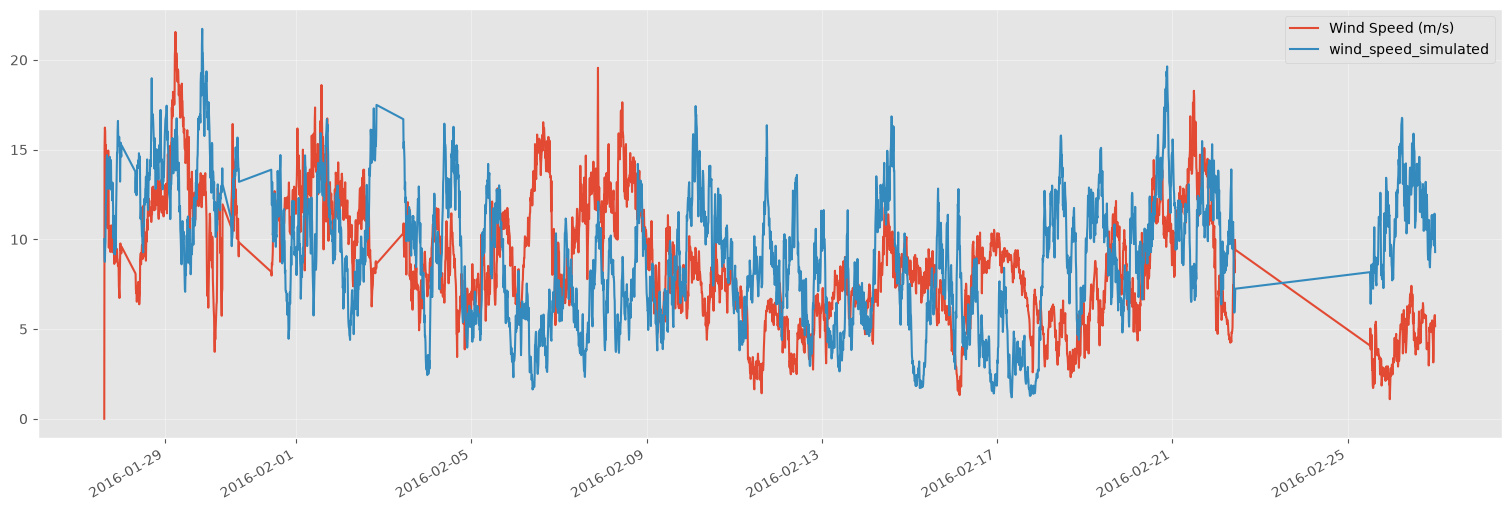

In [107]:
_, ax = plt.subplots(figsize=(15, 5), constrained_layout=True)
df.plot(ax=ax)